In [4]:
from DynamicModel import DynamicModel
from mod_stefan import StefanSolver
import logging
import numpy as np
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
math_vars = {
    'c_p': 4200,  # Specific heat capacity in J/(kg*K)
    'kappa': 0.6,  # Thermal conductivity in W/(m*K)
    'rho': 1000,  # Density in kg/m^3
    'T_l': 300,  # Liquid temperature in K
    'T_m': 273,  # Melting temperature in K
    'h_m': 100000,  # Enthalpy of melting in J/kg
    'timestep': 0.5,
}

model = DynamicModel(math_vars)
solver = StefanSolver(model)
model.set_solver(StefanSolver)
model.set_nondim_consts(
    #ref_l = 'x_L',
    ref_rho = 'rho',
    ref_kappa = 'kappa',
    ref_c_p = 'c_p',
    alpha = lambda ref_kappa, ref_rho, ref_c_p: ref_kappa / (ref_rho * ref_c_p)
    #ref_grev = 'grev',
    #ref_visc = 'low_visc',
    #ref_visc_kin = lambda ref_visc, ref_rho: ref_visc/ref_rho, 
    #ref_u = lambda ref_grev, ref_l: numpy.sqrt(ref_grev*ref_l),
    #ref_surface_tension = lambda ref_l, ref_rho, ref_u, surface_tension: ref_rho*ref_l*numpy.pow(ref_u, 2)*surface_tension
)

name_vars = {
    'x_dat': "X (m)",
    'y_dat': "Y (m)",
    'T': "Temperature (K)",
    "vof_ice": "Solid Volume Fraction of h2o",
    #'interface': 'vof_def'
}

dir_list = [
    r'/hpcwork/yy310050/thesis/HARD_DATA/STEFAN/1e-3',
    r'/hpcwork/yy310050/thesis/HARD_DATA/STEFAN/2e-3',
    r'/hpcwork/yy310050/thesis/HARD_DATA/STEFAN/5e-3',
    r'/hpcwork/yy310050/thesis/HARD_DATA/STEFAN/5e-4',
]
name = 'data_table_'
name_append = '.csv'

el_vol = [10E-7, 2E-6, 5E-6, 2.5E-7]

In [5]:
h_data = []
for idx, path in enumerate(dir_list):
    model.load_solution_data(
                            dir=path,
                            name=name,
                            name_append=name_append,
                            name_vars=name_vars,
                            timestep_from_file= True,
                            sort_by = "x_dat",
                            #ref_t=lambda ref_l, ref_u: ref_l/ref_u,
                            update_params=False)
    cur_h_data = {}
    analytical_interface = solver.interface_position(t_all = model.params['timesteps'])
    num_interface = solver.calculate_approx_interface_location()
    model.params['el_vol'] = el_vol[idx]
    L_inf, L2, err_abs = solver.calculate_errors()
    cur_h_data = {
        'name': path.split('/')[-1],
        'timesteps': model.params['timesteps'],
        "num_interface": num_interface,
        "analytical_interface": analytical_interface,
        "L_inf": L_inf,
        "L2": L2,
    }
    cur_h_data.update({"abs_err": np.abs(np.subtract(cur_h_data['num_interface'], cur_h_data['analytical_interface']))})
    #cur_h_data.update(model.analysis_data)
    h_data.append(cur_h_data)


/rwthfs/rz/cluster/hpcwork/yy310050/thesis/mod_stefan.py:63: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root, = fsolve(f_lam, lam_init)
/rwthfs/rz/cluster/hpcwork/yy310050/thesis/mod_stefan.py:63: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root, = fsolve(f_lam, lam_init)
/rwthfs/rz/cluster/hpcwork/yy310050/thesis/mod_stefan.py:63: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root, = fsolve(f_lam, lam_init)
/rwthfs/rz/cluster/hpcwork/yy310050/thesis/mod_stefan.py:63: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root, = fsolve(f_lam, lam_init)


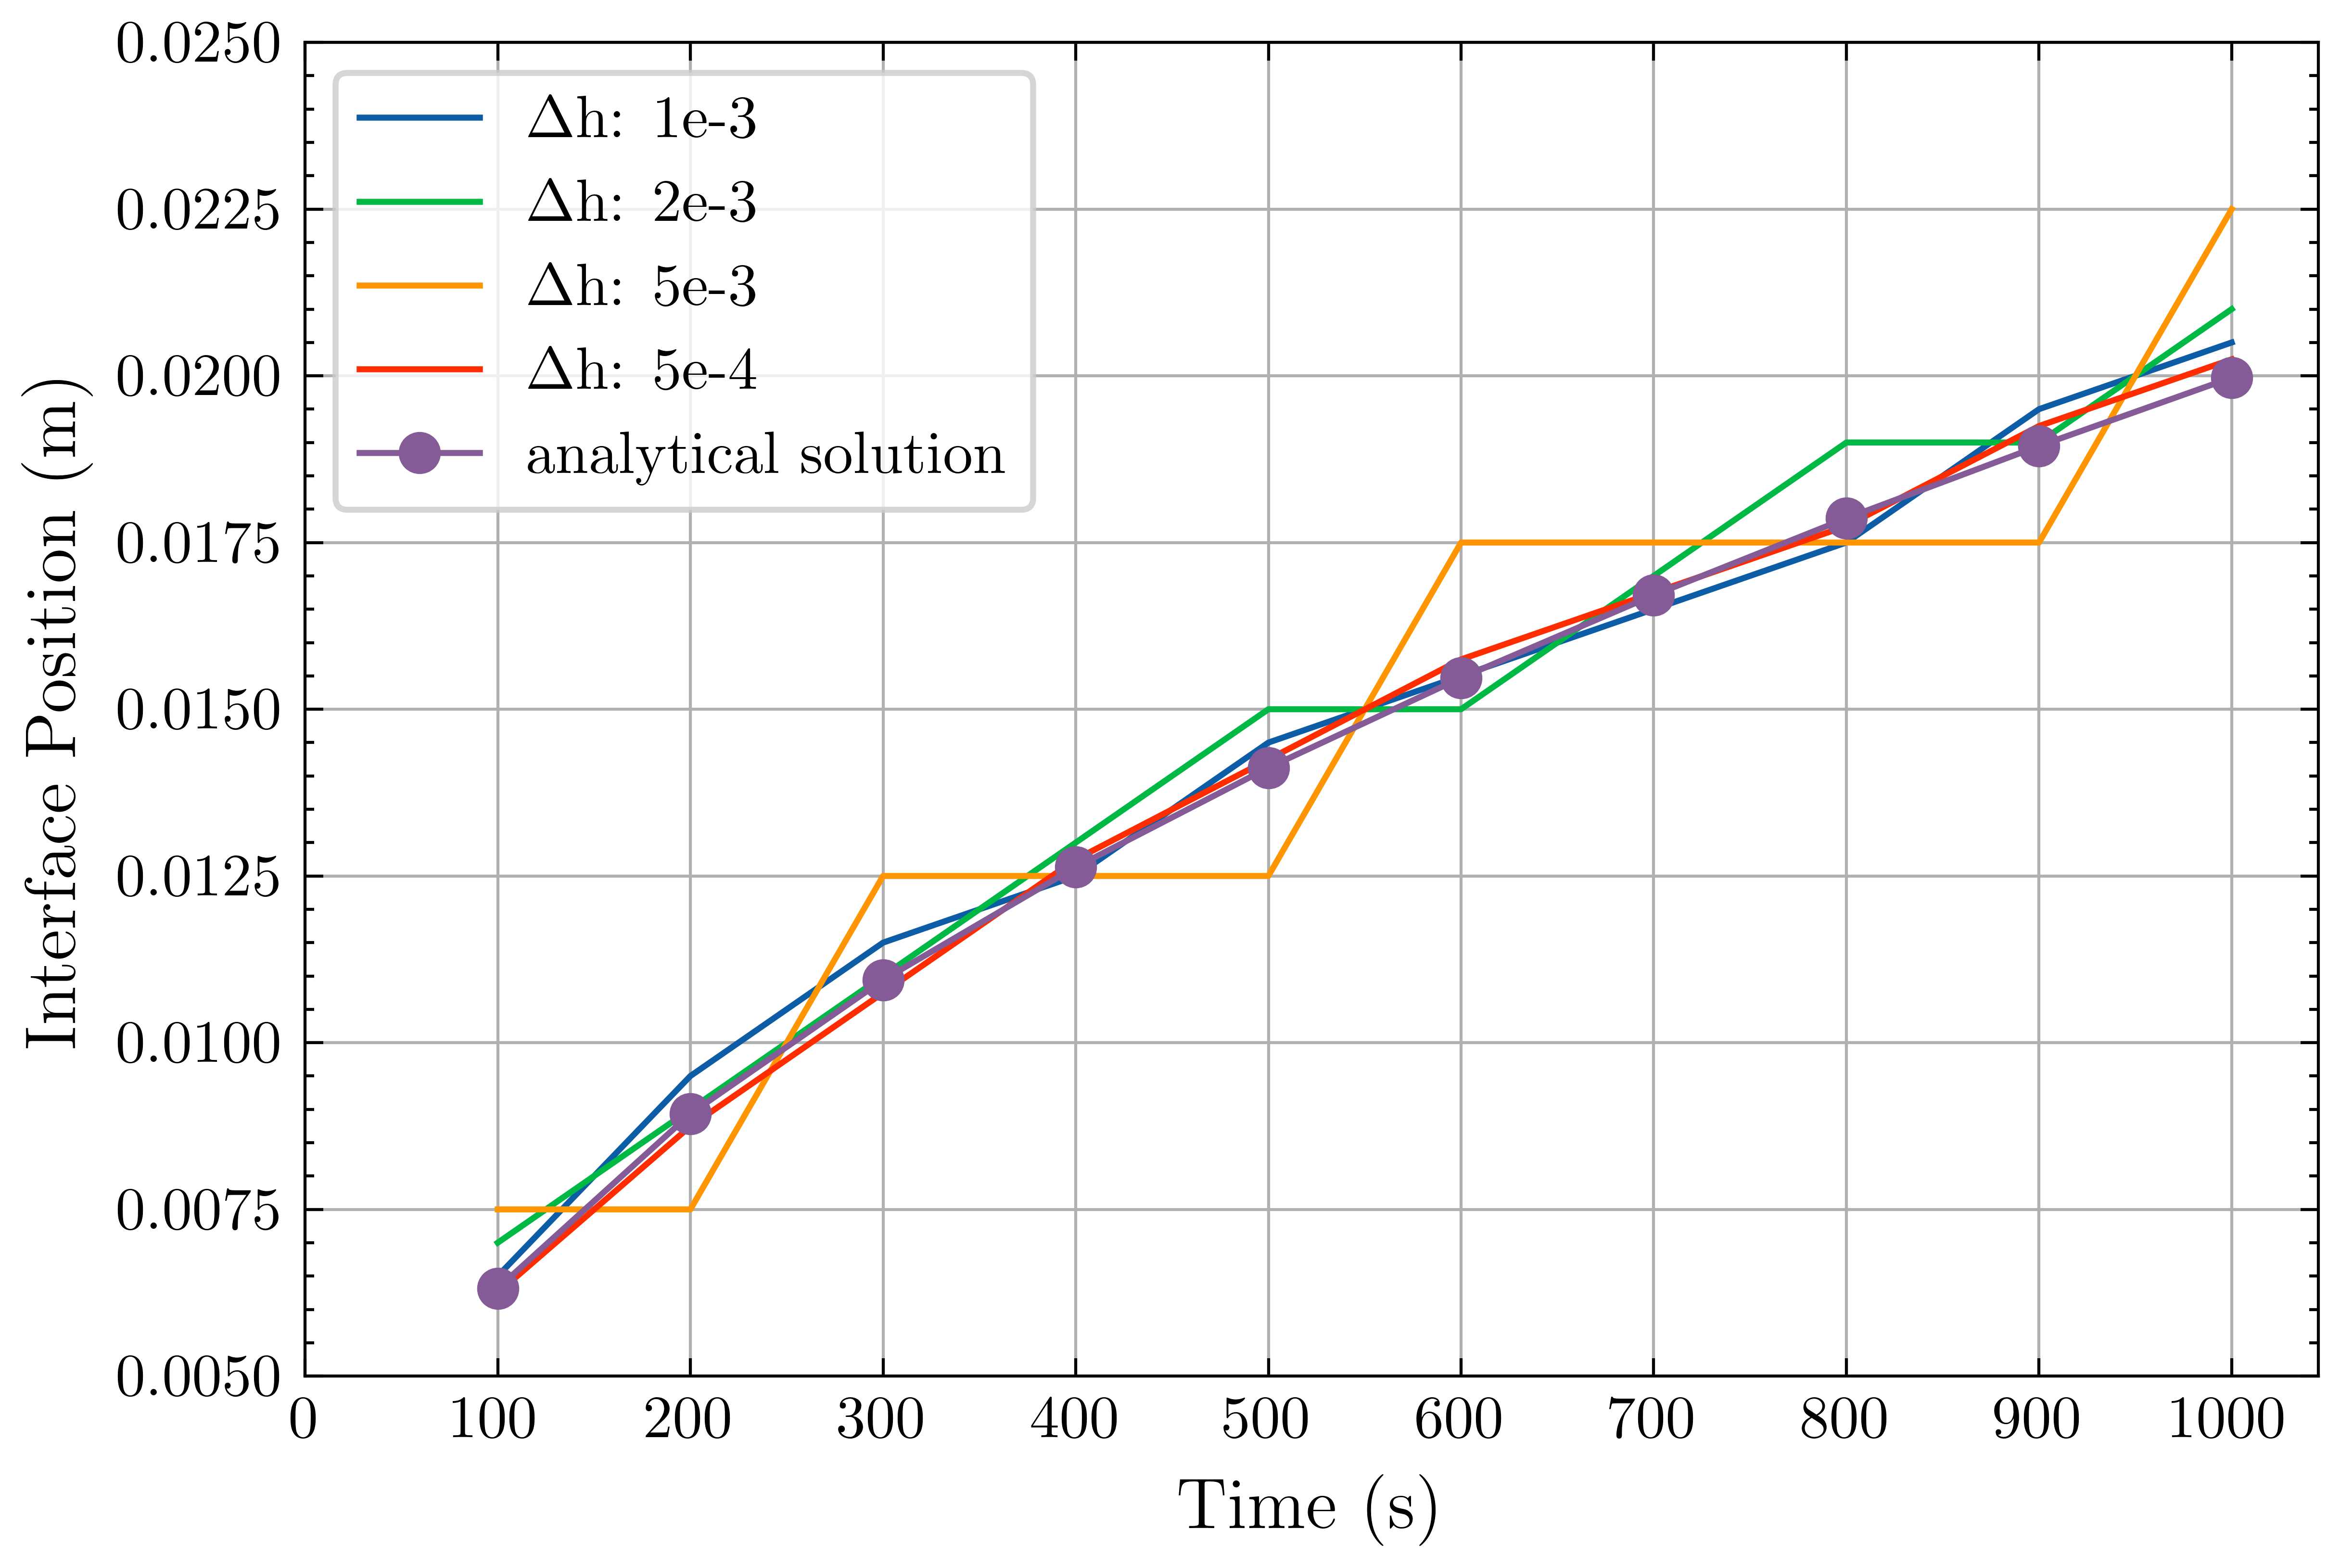

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
import tol_colors

plt.rcParams['axes.linewidth'] = 10
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Use only the "science" style for now:
plt.style.use(['science'])

fig, ax = plt.subplots(figsize=(6, 4), dpi=900)

for h in h_data:
    ax.plot(h['timesteps'], h['num_interface'], label=r"$\Delta \text{h}$" + f": {h['name']}")
ax.plot(
    h_data[0]['timesteps'], 
    h_data[0]['analytical_interface'], 
    marker='o', 
    label='analytical solution'
)

ax.set_ylim(0.0050, 0.025)
ax.set_xlim(0, None)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.0005))
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.NullLocator())

label_font = {'fontsize': 12, 'fontfamily': 'Arial'}
ax.set_xlabel("Time (s)", **label_font)
ax.set_ylabel("Interface Position (m)", **label_font)

legend_box = ax.legend(
    frameon=True,
    prop={'family': 'Arial', 'size': 10}
)

ax.grid(True)
plt.show()

New config line: axes.prop_cycle : cycler('color', ['4477AA', 'EE6677', '228833', 'CCBB44', '66CCEE', 'AA3377', 'BBBBBB'])
Injecting line in file '/rwthfs/rz/cluster/home/yy310050/.config/matplotlib/matplotlibrc'


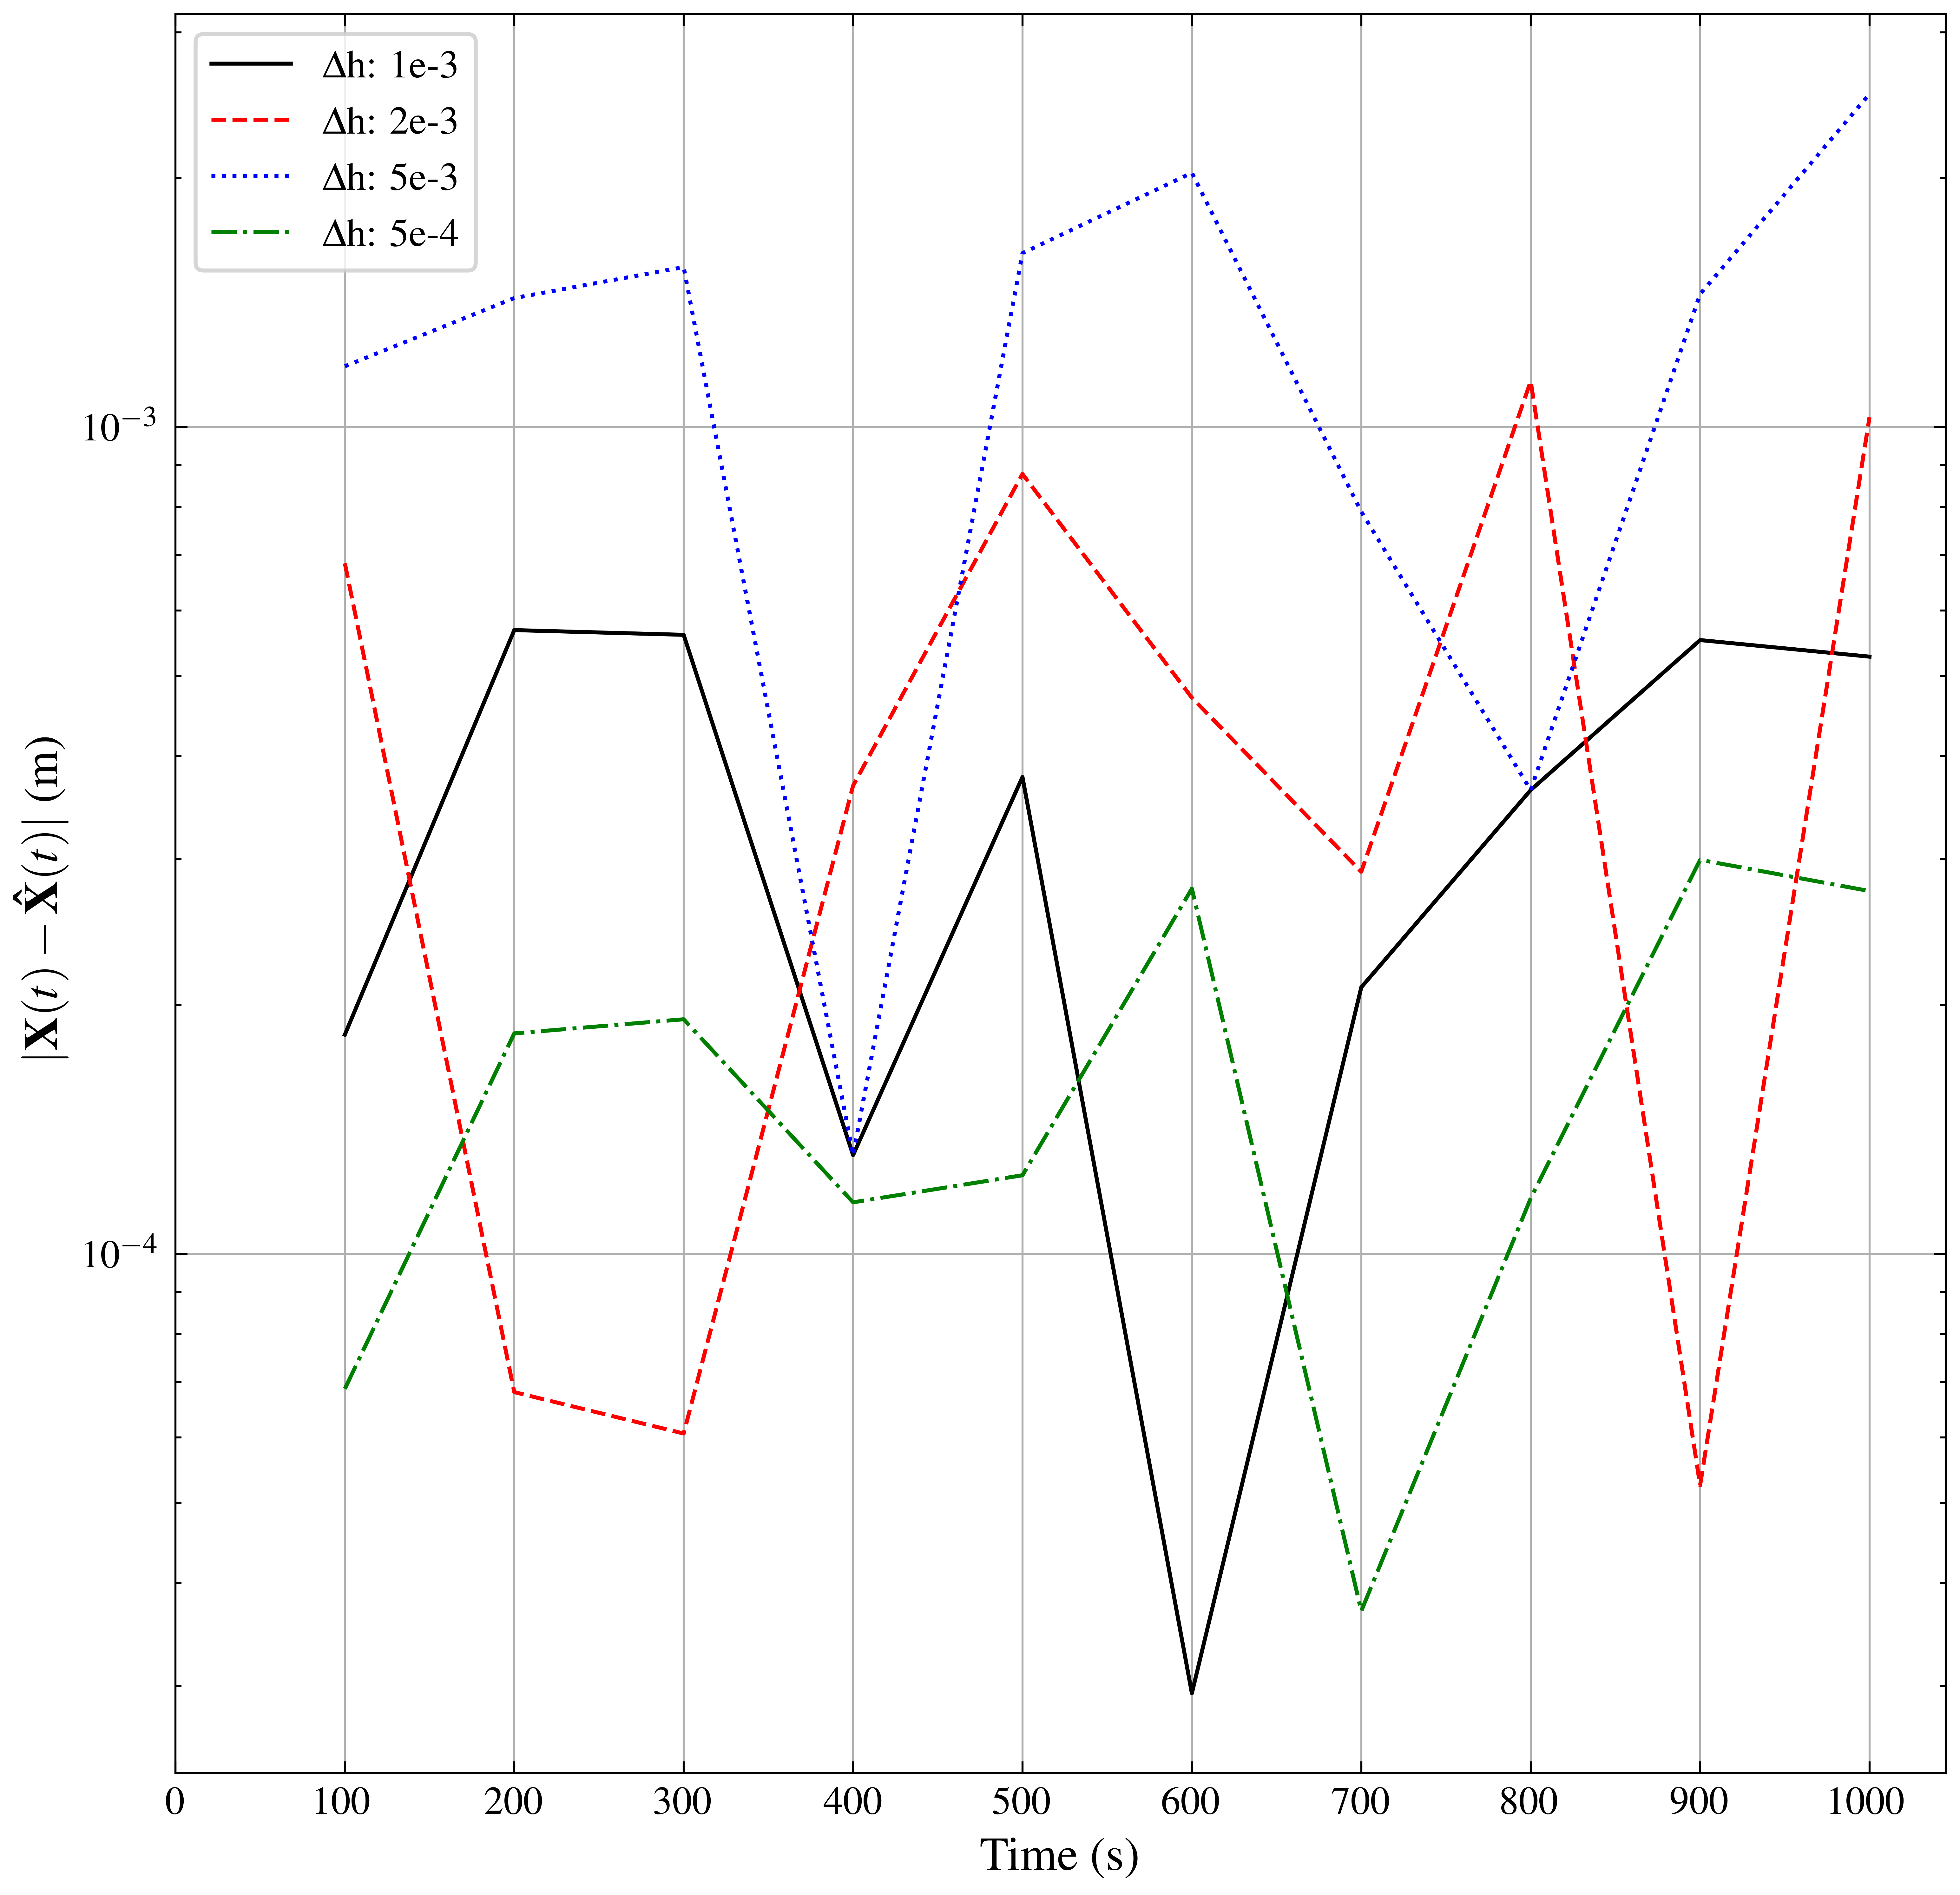

In [7]:
plt.rcParams['axes.linewidth'] = 10
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10


plt.style.use(['science', 'ieee'])
tol_colors.set_default_colors(cset='bright')
fig, ax = plt.subplots(figsize=(8, 8), dpi=900)

for h in h_data:
    ax.plot(h['timesteps'], h['abs_err'], label=r"$\Delta \text{h}$" + f": {h['name']}")
ax.set_yscale('log')
ax.set_xlim(0, None)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.NullLocator())

label_font = {'fontsize': 12, 'fontfamily': 'Arial'}
ax.set_xlabel("Time (s)", **label_font)
ax.set_ylabel(r"$|\mathbf{X}(t) - \mathbf{\hat{X}}(t)|$ (m)", **label_font)

legend_box = ax.legend(
    frameon=True,
    prop={'family': 'Arial', 'size': 10}
)

ax.grid(True)
plt.show()

New config line: axes.prop_cycle : cycler('color', ['4477AA', 'EE6677', '228833', 'CCBB44', '66CCEE', 'AA3377', 'BBBBBB'])
Injecting line in file '/rwthfs/rz/cluster/home/yy310050/.config/matplotlib/matplotlibrc'


/tmp/yy310050/login23-3_38165/ipykernel_52387/994041994.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend_box = ax.legend(


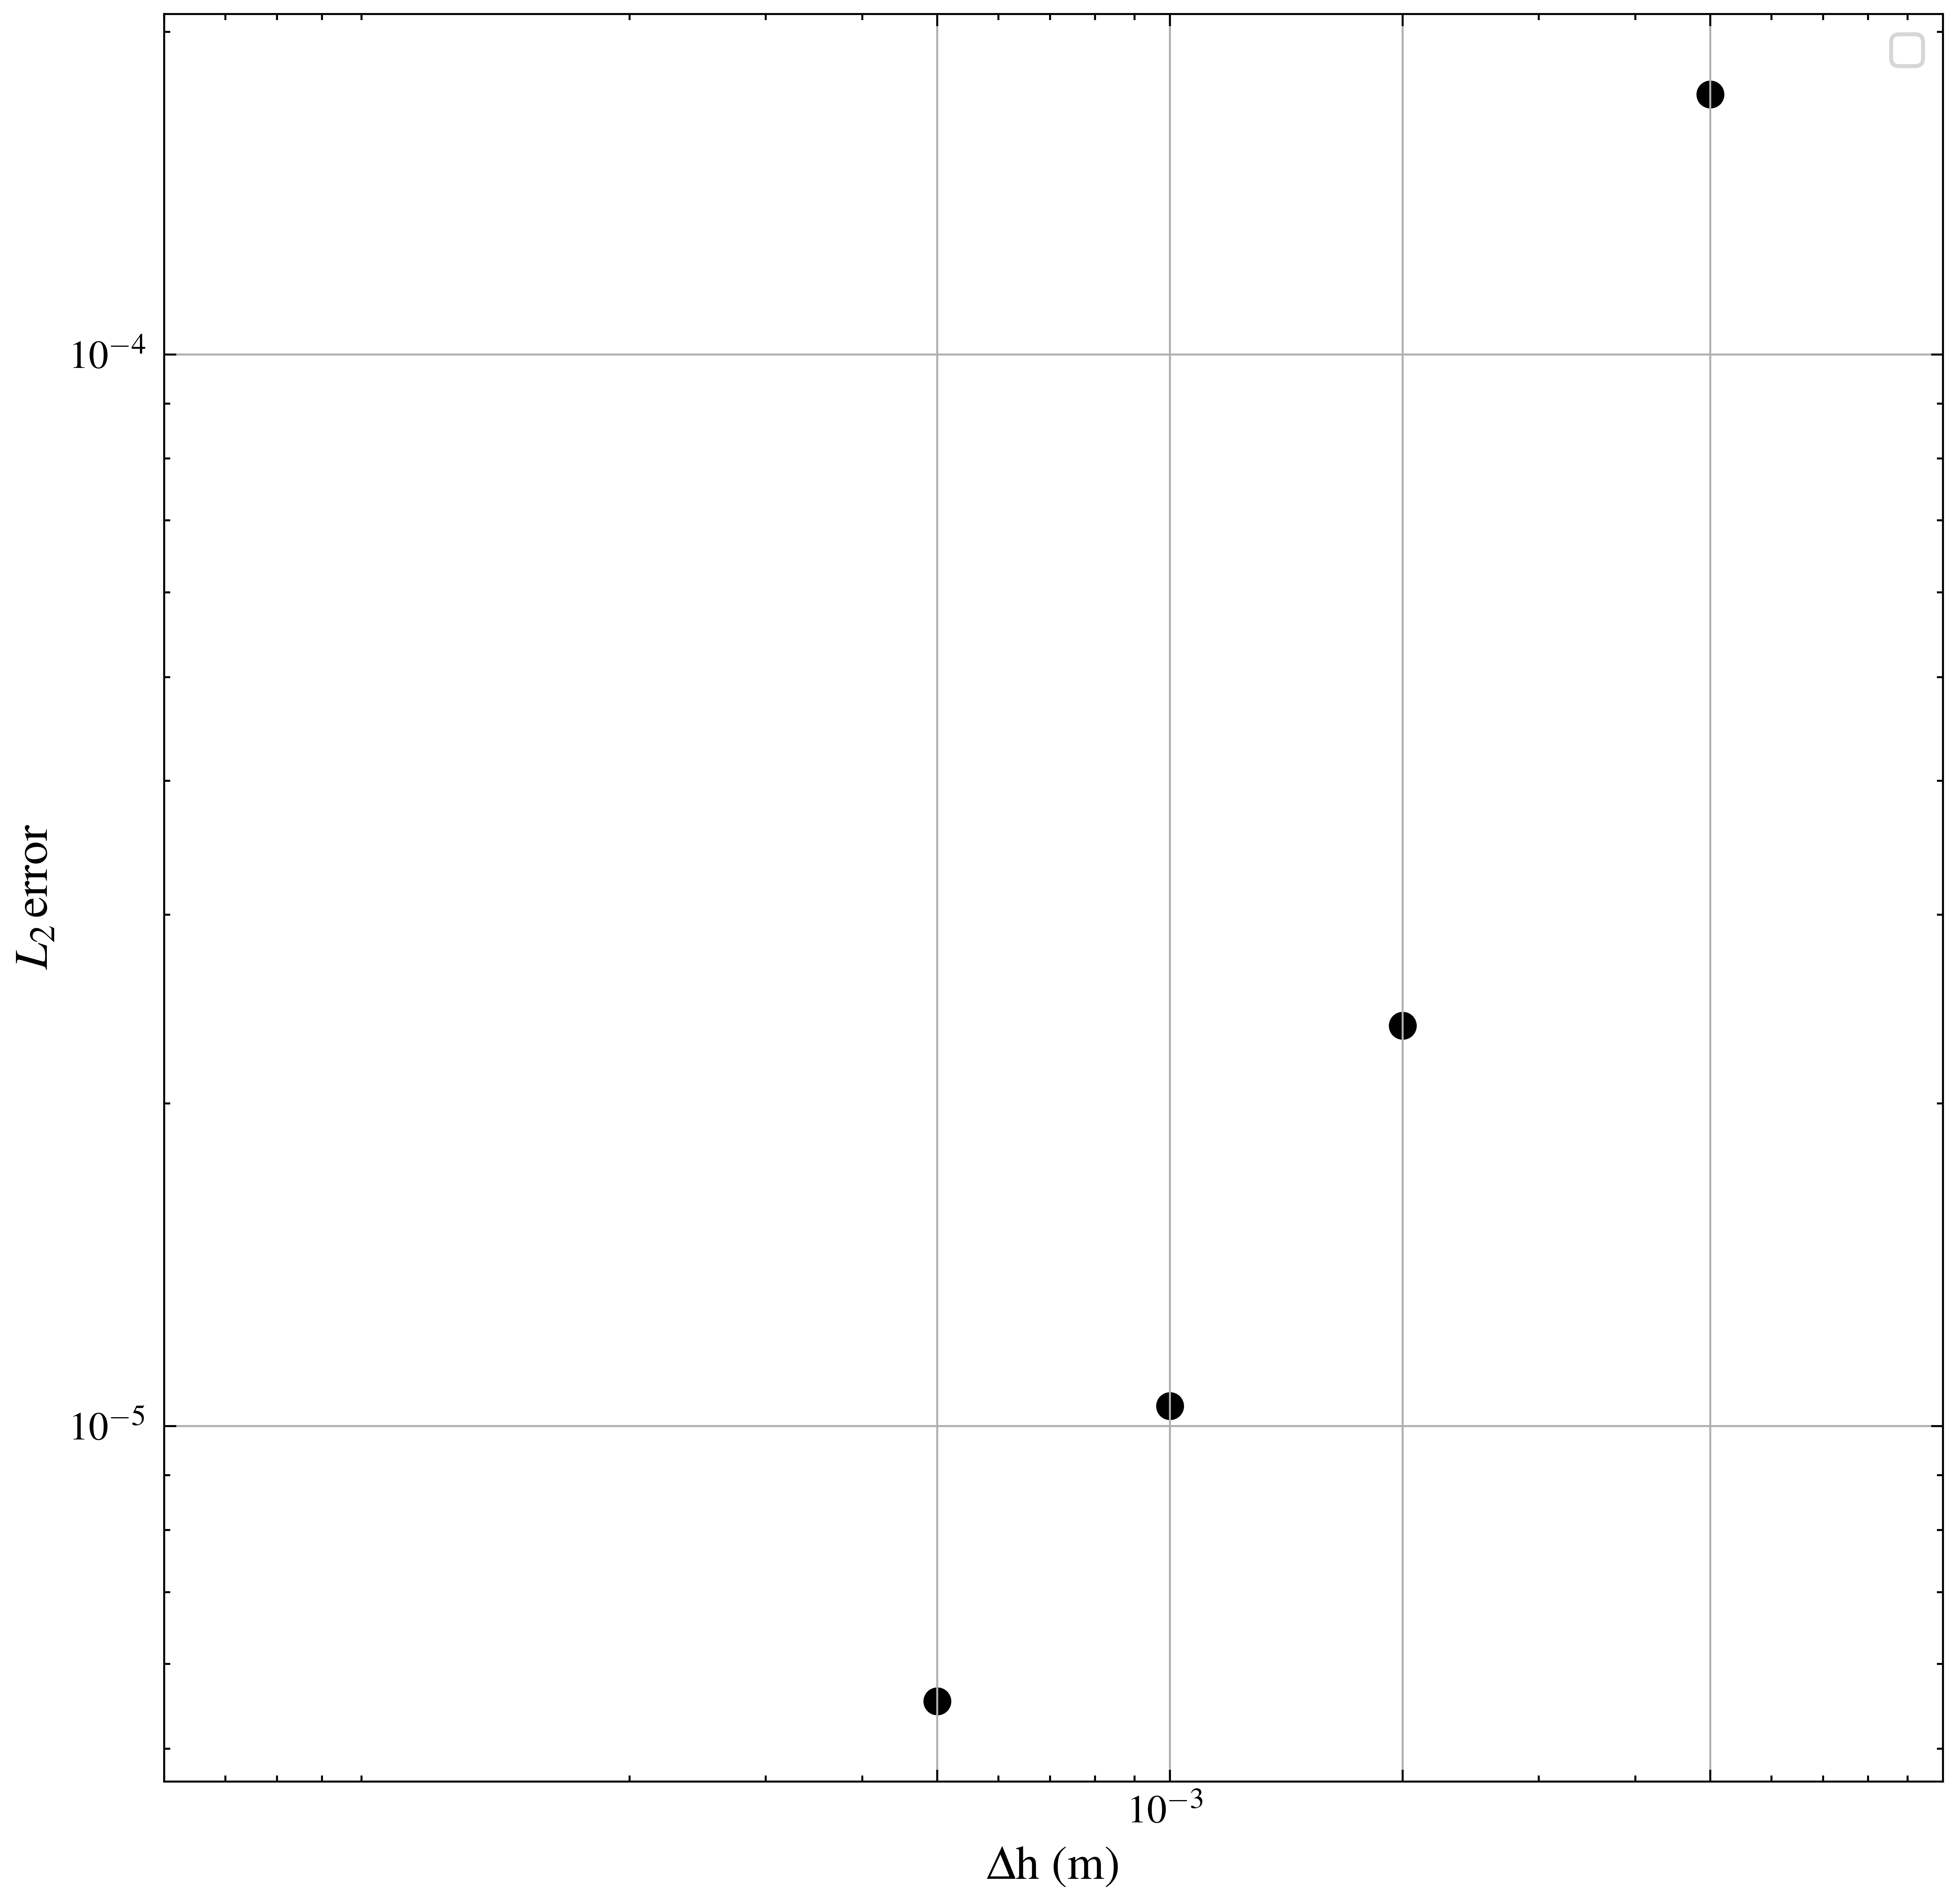

In [10]:
plt.rcParams['axes.linewidth'] = 10
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10


plt.style.use(['science', 'ieee'])
tol_colors.set_default_colors(cset='bright')
fig, ax = plt.subplots(figsize=(8, 8), dpi=900)

# Gather data into lists for a single line plot:
x_vals = [float(h['name']) for h in h_data]   # Convert h['name'] to float for x
y_vals = [np.mean(h['L2']) for h in h_data]   # Take mean L2 for y

# Plot as a dashed line with markers
ax.scatter(x_vals, y_vals, marker='o')

# Set log scales
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(5E-5, 1E-2)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# Make ticks appear exactly where your data points are:
ax.set_xticks(x_vals)
label_font = {'fontsize': 12, 'fontfamily': 'Arial'}
ax.set_xlabel(r"$\Delta \text{h}$ (m)" , **label_font)
ax.set_ylabel(r"$L_{2}\,\text{error}$", **label_font)

legend_box = ax.legend(
    frameon=True,
    prop={'family': 'Arial', 'size': 10}
)

ax.grid(True)
plt.show()